In [ ]:
#3b
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import tensorflow as tf

In [ ]:

df = tf.keras.datasets.fashion_mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = df.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


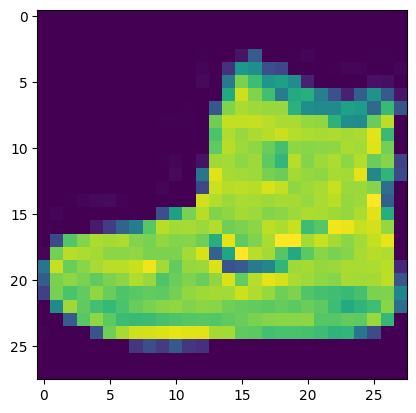

In [ ]:
plt.imshow(X_train[0])
plt.show()

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape = (28,28,1)
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.8586 - loss: 0.4009
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9019 - loss: 0.2681
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 21ms/step - accuracy: 0.9166 - loss: 0.2230
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9297 - loss: 0.1898
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9401 - loss: 0.1604


In [ ]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
predicted_class = np.argmax(y_pred[0])
print(predicted_class)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(class_names[predicted_class])

9
Ankle boot


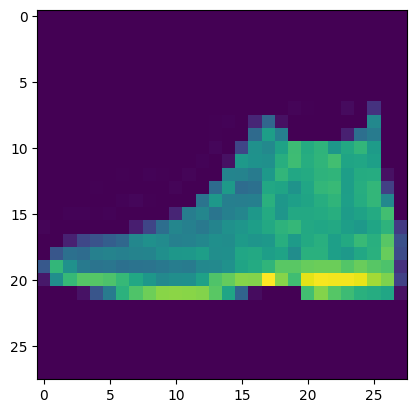

In [ ]:
plt.imshow(X_test[0].reshape(28,28))

plt.show()

In [ ]:
#3a untested

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling
# Define standard image size and batch size
img_height = 128
img_width = 128
batch_size = 32
data_dir = "./Potato" # Make sure your extracted dataset folder is named this

print("Loading Training Data:")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

print("\nLoading Validation Data:")
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

# Extract the class names (the names of your subfolders)
class_names = train_ds.class_names
print(f"\nClasses found: {class_names}")
num_classes = len(class_names)

model = Sequential()

# 1. Normalization Layer
model.add(Rescaling(1./255, input_shape=(img_height, img_width, 3)))

# 2. First Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3. Second Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 4. Third Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 5. Flatten and Dense Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10
)

In [ ]:
for images, labels in val_ds.take(1):
    test_image = images[0]
    actual_label = labels[0]

    # Model expects a batch, so we expand dimensions
    img_array = tf.expand_dims(test_image, 0)

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])

    # Display the image
    plt.imshow(test_image.numpy().astype("uint8"))
    plt.title(f"Actual: {class_names[actual_label]}\nPredicted: {class_names[predicted_class]}")
    plt.axis("off")
    plt.show()